In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

In [26]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            # why kernel size 3 and padding1?
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            # saves memory
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
    
class DownSample(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.conv= DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)
        # why down and p? skip connectons
        return down, p 

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # concat skip connection x2 with x1
        x = torch.cat([x1,x2], dim=1)
        return self.conv(x)

In [25]:
class UNET(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        # third conv at end
        # kernell size 1 why?
        self.out = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x):  
        """nested forward, run the forward of down_convolution_1, which is class DownSample forward method
        """
        down1, p1 = self.down_convolution_1(x)
        down2, p2 = self.down_convolution_2(p1)
        down3, p3 = self.down_convolution_3(p2)
        down4, p4 = self.down_convolution_4(p3)
        b = self.bottleneck(p4)
        up1 = self.up_convolution_1(b, down4)
        up2 = self.up_convolution_2(up1, down3)
        up3 = self.up_convolution_3(up2, down2)
        up4 = self.up_convolution_4(up3, down1)
        
        # call last layer
        out = self.out(up4)
        return out


In [35]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        re_size = (128, 128)

        # resize and to tensor for the image
        self.img_transform = transforms.Compose([
            transforms.Resize((re_size)),
            transforms.ToTensor()
        ])

        # for the mask,
        self.mask_transform = transforms.Compose([
            transforms.Resize(re_size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor() 
        ])
    
    def __getitem__(self, idx):
        img, mask = self.dataset[idx] 
        
        img = img.convert("RGB")
        
        # 2. Apply our transforms
        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        
        # 3. Format mask for Binary Cross Entropy
        mask = torch.where(mask == 1, 1.0, 0.0)
        
        return img, mask

    def __len__(self):
        return len(self.dataset)

In [36]:
if __name__ == "__main__":
    # double_conv = DoubleConv(64, 64)

    # pytorch always batch, channel, size
    input_image = torch.rand((1, 3, 512, 512))
    model = UNET(in_channels=3, num_classes=1)
    output = model(input_image)
    # input size should be same as output
    print(output.shape)

torch.Size([1, 1, 512, 512])


## dataset

In [37]:
from torch.utils.data.dataset import Dataset
from torchvision import transforms
import tqdm
from PIL import Image

from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt

In [38]:
raw_train = OxfordIIITPet(root="./data", split="trainval", target_types="segmentation", download=True)
raw_val = OxfordIIITPet(root="./data", split="test", target_types="segmentation", download=True)

train_ds = CustomDataset(raw_train)
val_ds = CustomDataset(raw_val)


(394, 500)


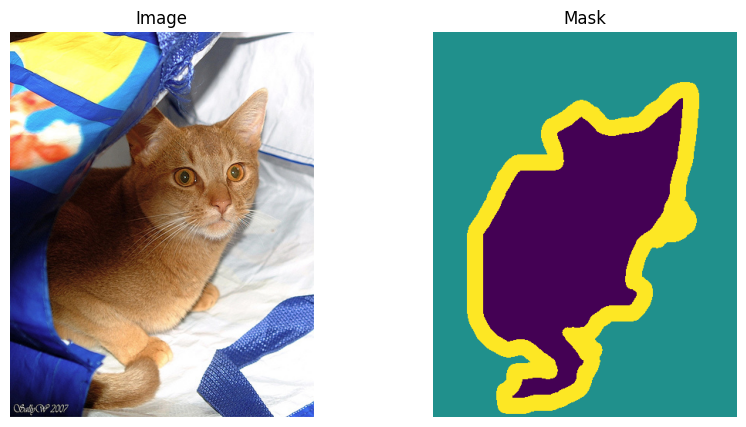

In [39]:
raw_train = OxfordIIITPet(root="./data", split="trainval", target_types="segmentation", download=True)
    # raw_val = OxfordIIITPet(root="./data", split="test", target_types="segmentation", download=True)
img, mask = raw_train[0]
print(img.size)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Mask")
ax[1].axis("off")

plt.show()

In [46]:
type(train_ds)

__main__.CustomDataset

torch.Size([3, 128, 128])


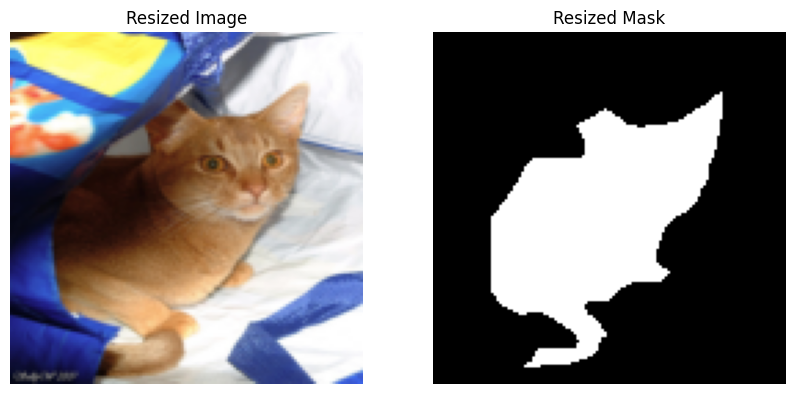

In [40]:
train_ds = CustomDataset(raw_train)

img, mask = train_ds[0]
print(img.shape)
img_np = img.permute(1, 2, 0).numpy()
mask_np = mask.squeeze(0).numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_np)
ax[0].set_title("Resized Image")
ax[0].axis("off")

ax[1].imshow(mask_np, cmap="gray")
ax[1].set_title("Resized Mask")
ax[1].axis("off")

plt.show()

In [35]:
a = tor.rec

NameError: name 'tor' is not defined

In [45]:
if __name__ == "__main__":
    LEARINING_RATE = 3e-4
    BATCH_SIZE = 16
    NUM_EPOCHS = 5
    
    MODEL_SAVE_PATH = "./models/unet.pth"
    # MODEL_SAVE_PATH = MODEL_SAVE_PATH
    
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print(f"Using {device} device")

    raw_train = OxfordIIITPet(root="./data", split="trainval", target_types="segmentation", download=True)
    raw_val = OxfordIIITPet(root="./data", split="test", target_types="segmentation", download=True)

    train_ds = CustomDataset(raw_train)
    val_ds = CustomDataset(raw_val)
    
    # random seed for train_laoder, liek random seed
    generator = torch.Generator().manual_seed(1)
    
    # batch, shuffle ...
    # returns batch, channel, h, w
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = UNET(in_channels=3, num_classes=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARINING_RATE)
    loss_fn = nn.BCEWithLogitsLoss()
    
    for epoch in tqdm.tqdm(range(NUM_EPOCHS)):
        # Training phase
        model.train()
        train_running_loss = 0.0
        # batch,(channel) image, mask
        for batch, (images, masks) in (enumerate(train_loader)):
            # move to device, m5 chip
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            y_pred = model(images)
            loss = loss_fn(y_pred, masks)
            
            loss.backward()
            optimizer.step()
            # avg over batches-> sum up the losses/batch size, .item() turn tensor to scalar
            train_running_loss += loss.item()
        
        train_loss = train_running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Training Loss: {train_loss:.4f}")

        model.eval()
        val_running_loss = 0.0

        # dont change grad, save computation
        with torch.no_grad():
            for batch, (images, masks) in tqdm.tqdm(enumerate(val_loader)):
                images = images.to(device)
                masks = masks.to(device)

                y_pred = model(images)
                loss = loss_fn(y_pred, masks)
                val_running_loss += loss.item()
        
        val_loss = val_running_loss / len(val_loader)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Validation Loss: {val_loss:.4f}")
        
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

Using mps device


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5, Training Loss: 0.5027


230it [00:40,  5.62it/s]
 20%|██        | 1/5 [02:35<10:20, 155.22s/it]

Epoch 1/5, Validation Loss: 0.4712
Epoch 2/5, Training Loss: 0.4368


...

Epoch 3/5, Validation Loss: 0.4033
Epoch 4/5, Training Loss: 0.3934


230it [00:46,  4.91it/s]
 80%|████████  | 4/5 [11:47<03:01, 181.61s/it]

Epoch 4/5, Validation Loss: 0.3718
Epoch 5/5, Training Loss: 0.3570


230it [00:47,  4.85it/s]
100%|██████████| 5/5 [14:52<00:00, 178.51s/it]

Epoch 5/5, Validation Loss: 0.3371


### load model weightsand biases, skip trainingagain

In [ ]:
import torch

# Rebuild the exact same empyt model architecture
device = "mps" if torch.backends.mps.is_available() else "cpu"
model = UNET(in_channels=3, num_classes=1)

# load the weights from the file (map_location ensures it loads on the right chip)
# weights_only=True is a modern PyTorch security best practice
saved_weights = torch.load("./models/unet.pth", map_location=device, weights_only=True)
model.load_state_dict(saved_weights)

# 3. Move the model to your M-series chip or CPU
model = model.to(device)

# Put the model in evaluation mode
model.eval()

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


## inference

Testing image #1049 from the validation set...
tensor([[[[-2.8683, -3.6585, -3.9924,  ..., -3.7477, -3.6358, -2.4361],
          [-3.6022, -3.6697, -3.7795,  ..., -3.7807, -3.7513, -3.2961],
          [-3.8477, -3.7323, -3.7156,  ..., -3.8548, -3.9626, -3.6703],
          ...,
          [-2.9920, -2.7339, -2.4286,  ..., -1.5176, -1.6453, -1.5258],
          [-2.7108, -2.6559, -2.3973,  ..., -1.5731, -1.6059, -1.4467],
          [-2.0234, -2.6880, -2.6141,  ..., -1.6045, -1.5754, -1.1613]]]],
       device='mps:0')


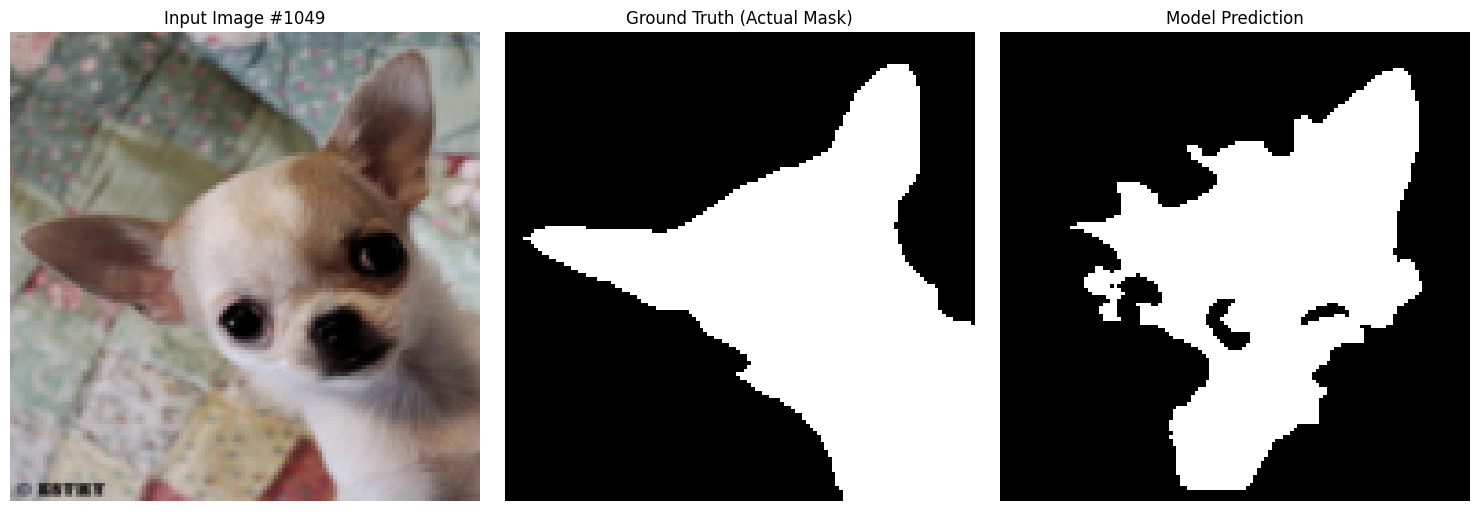

In [46]:
import torch
import matplotlib.pyplot as plt
import random


def test_validation_image(model_path, val_dataset, device, image_index=None):
    # 1. Pick an image index (random if none is provided)
    if image_index is None:
        image_index = random.randint(0, len(val_dataset) - 1)
        
    print(f"Testing image #{image_index} from the validation set...")
    
    # 2. Grab the processed tensor and true mask directly from your dataset
    # (Because it comes from CustomDataset, it's already resized and formatted!)
    img_tensor, true_mask_tensor = val_dataset[image_index]
    
    # 3. Add the fake batch dimension for the model: [3, 64, 64] -> [1, 3, 64, 64]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 4. Load the trained model
    model = UNET(in_channels=3, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    # 5. Make the prediction
    with torch.no_grad():
        raw_output = model(input_tensor)
        print(raw_output)  # Should be [1, 1, 64, 64]
        probabilities = torch.sigmoid(raw_output)
        predicted_mask = (probabilities > 0.5).float() # Threshold at 50%
        
    # 6. Clean up the shapes so Matplotlib can read them
    display_image = img_tensor.cpu().permute(1, 2, 0) # Rearrange to [Height, Width, Channels]
    true_mask = true_mask_tensor.squeeze().cpu()      # Remove extra dimensions
    predicted_mask = predicted_mask.squeeze().cpu()   
    
    # 7. Plot Original vs. True Mask vs. Predicted Mask
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(display_image)
    axes[0].set_title(f"Input Image #{image_index}")
    axes[0].axis('off')
    
    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title("Ground Truth (Actual Mask)")
    axes[1].axis('off')
    
    axes[2].imshow(predicted_mask, cmap='gray')
    axes[2].set_title("Model Prediction")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    # Assuming val_ds and device are already defined in your script above!
    MODEL_PATH = "./models/unet.pth"
    
    # Run this to test a completely random image from the validation set:
    test_validation_image(MODEL_PATH, val_ds, device, 1049)
    
    # Or, uncomment this to test a specific image by its index number:
    # test_validation_image(MODEL_PATH, val_ds, device, image_index=42)

## lrp



In [47]:
import torch
import matplotlib.pyplot as plt
import random
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

def test_validation_image_global_lrp(model_path, val_dataset, device, image_index=None):
    if image_index is None:
        image_index = random.randint(0, len(val_dataset) - 1)
        
    img_tensor, true_mask_tensor = val_dataset[image_index]
    # one batch dimension for the model (cause only one image)
    input_tensor = img_tensor.unsqueeze(0).to(device)
    # require grad
    input_tensor.requires_grad_()
    
    model = UNET(in_channels=3, num_classes=1).to(device)
    # load pretrained weights
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    # 1. Forward Pass
    with torch.no_grad():
        raw_output = model(input_tensor)
        #  segmentation task, use sigmoid(raw output)
        probabilities = torch.sigmoid(raw_output)
        # treshold 0.5 (class a 0, class b 1)
        predicted_mask = (probabilities > 0.5).float()

        
    
    grad_output_mask = predicted_mask.clone() 
    
    # precoded lrp layers
    composite = EpsilonGammaBox(low=0.0, high=1.0)
    
    # do the lrp things
    with Gradient(model=model, composite=composite) as attributor:
        _, attribution = attributor(input_tensor, grad_output_mask)

        
    # Sum the relevance across color channels
    # cpu detach for matpliot
    lrp_heatmap = attribution.squeeze().sum(dim=0).cpu().detach()
    
    # 3. Visualization Formatting
    display_image = img_tensor.cpu().detach().permute(1, 2, 0)
    true_mask = true_mask_tensor.squeeze().cpu()      
    predicted_mask_sq = predicted_mask.squeeze().cpu()
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(display_image)
    axes[0].set_title(f"Input Image #{image_index}")
    axes[0].axis('off')
    
    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title("Ground Truth")
    axes[1].axis('off')
    
    axes[2].imshow(predicted_mask_sq, cmap='gray')
    axes[2].set_title("Full Prediction Mask")
    axes[2].axis('off')
    
    vmax = torch.max(torch.abs(lrp_heatmap))
    im = axes[3].imshow(lrp_heatmap, cmap='bwr', vmin=-vmax, vmax=vmax)
    axes[3].set_title("Global LRP Relevance (Whole Mask)")
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

mps


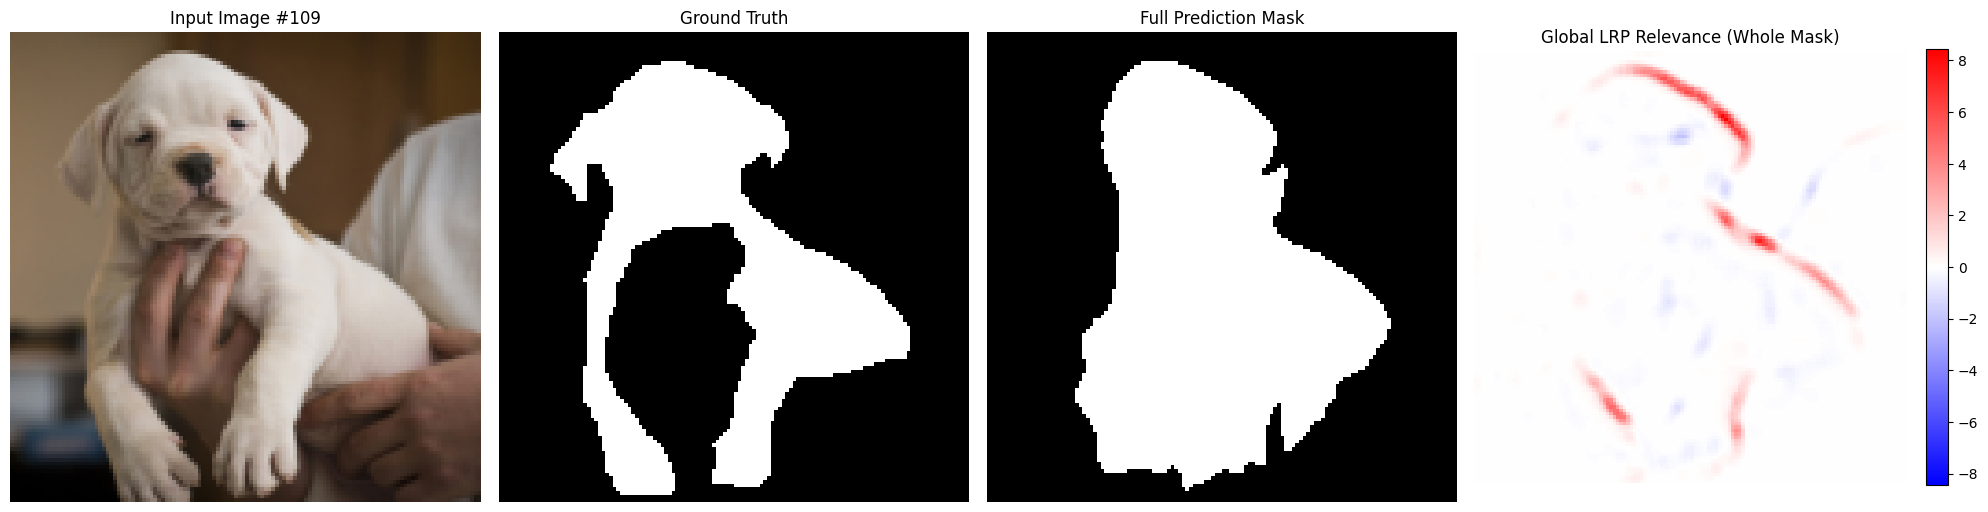

In [48]:
if __name__ == "__main__":
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    
    print(device)
    # Assuming val_ds and device are already defined in your script above!
    MODEL_PATH = "./models/unet.pth"
    
    # Run this to test a completely random image from the validation set:
    test_validation_image_global_lrp(MODEL_PATH, val_ds, device, 109)

In [49]:
import torch
import matplotlib.pyplot as plt
import random
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

def test_validation_image_balanced_lrp(model_path, val_dataset, device, image_index=None):
    if image_index is None:
        image_index = random.randint(0, len(val_dataset) - 1)
        
    img_tensor, true_mask_tensor = val_dataset[image_index]
    # one batch dimension for the model (cause only one image)
    input_tensor = img_tensor.unsqueeze(0).to(device)
    # require grad
    input_tensor.requires_grad_()
    
    model = UNET(in_channels=3, num_classes=1).to(device)
    # load pretrained weights
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    # 1. Forward Pass
    with torch.no_grad():
        raw_output = model(input_tensor)
        # segmentation task, use sigmoid(raw output)
        probabilities = torch.sigmoid(raw_output)
        # treshold 0.5 (class a 0, class b 1)
        predicted_mask = (probabilities > 0.5).float()

    # =================================================================
    # 2. IMPLEMENTING SECTION 2.3: M0 (Background) and M1 (Foreground)
    # =================================================================
    
    # Find coordinates for M1 (Tumor/Mask) and M0 (Background)
    tumor_coords = torch.nonzero(predicted_mask == 1)
    bg_coords = torch.nonzero(predicted_mask == 0)
    
    # Balance the voxels/pixels to prevent background bias
    min_voxels = min(len(tumor_coords), len(bg_coords))
    
    if min_voxels == 0:
        print("Warning: No mask predicted. Cannot balance classes. Falling back to whole mask.")
        M_combined_mask = predicted_mask.clone()
    else:
        # Randomly sample 'min_voxels' to balance classes
        tumor_indices = torch.randperm(len(tumor_coords))[:min_voxels]
        bg_indices = torch.randperm(len(bg_coords))[:min_voxels]
        
        sampled_tumor_coords = tumor_coords[tumor_indices]
        sampled_bg_coords = bg_coords[bg_indices]
        
        # Create the balanced gradient masks
        M_T_mask = torch.zeros_like(predicted_mask)
        M_B_mask = torch.zeros_like(predicted_mask)
        
        for coord in sampled_tumor_coords:
            M_T_mask[tuple(coord)] = 1.0
            
        for coord in sampled_bg_coords:
            M_B_mask[tuple(coord)] = 1.0

    # precoded lrp layers
    composite = EpsilonGammaBox(low=0.0, high=1.0)
    
    # do the lrp things
    with Gradient(model=model, composite=composite) as attributor:
        if min_voxels > 0:
            # Calculate M1_T (Foreground Relevance)
            _, M_T_attr = attributor(input_tensor, M_T_mask)
            # Calculate M0_B (Background Relevance)
            _, M_B_attr = attributor(input_tensor, M_B_mask)
            # Combine them: M = M0_B + M1_T
            attribution = M_T_attr + M_B_attr
        else:
            _, attribution = attributor(input_tensor, M_combined_mask)

    # =================================================================
    # 3. Channel Importance Printout (From Paper)
    # =================================================================
    # Sum spatially across H and W (dims 2 and 3), take absolute value, and normalize
    channel_relevance = torch.abs(attribution.sum(dim=(2, 3)).squeeze())
    channel_importance = channel_relevance / channel_relevance.sum()
    
    print(f"\n--- Channel Importance (Section 2.3) ---")
    print(f"Channel 0 (Red) Importance:   {channel_importance[0].item() * 100:.2f}%")
    print(f"Channel 1 (Green) Importance: {channel_importance[1].item() * 100:.2f}%")
    print(f"Channel 2 (Blue) Importance:  {channel_importance[2].item() * 100:.2f}%")
    print(f"----------------------------------------\n")

    # =================================================================
    # 4. Visualization Formatting
    # =================================================================
    # Sum the relevance across color channels for spatial heatmap plotting
    # cpu detach for matplotlib
    lrp_heatmap = attribution.squeeze().sum(dim=0).cpu().detach()
    
    display_image = img_tensor.cpu().detach().permute(1, 2, 0)
    true_mask = true_mask_tensor.squeeze().cpu()      
    predicted_mask_sq = predicted_mask.squeeze().cpu()
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(display_image)
    axes[0].set_title(f"Input Image #{image_index}")
    axes[0].axis('off')
    
    axes[1].imshow(true_mask, cmap='gray')
    axes[1].set_title("Ground Truth")
    axes[1].axis('off')
    
    axes[2].imshow(predicted_mask_sq, cmap='gray')
    axes[2].set_title("Full Prediction Mask")
    axes[2].axis('off')
    
    vmax = torch.max(torch.abs(lrp_heatmap))
    if vmax == 0: vmax = 1.0 # Prevent division by zero if heatmap is blank
    
    im = axes[3].imshow(lrp_heatmap, cmap='bwr', vmin=-vmax, vmax=vmax)
    axes[3].set_title("Balanced LRP (M0 + M1)")
    axes[3].axis('off')
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

mps

--- Channel Importance (Section 2.3) ---
Channel 0 (Red) Importance:   37.41%
Channel 1 (Green) Importance: 29.09%
Channel 2 (Blue) Importance:  33.49%
----------------------------------------



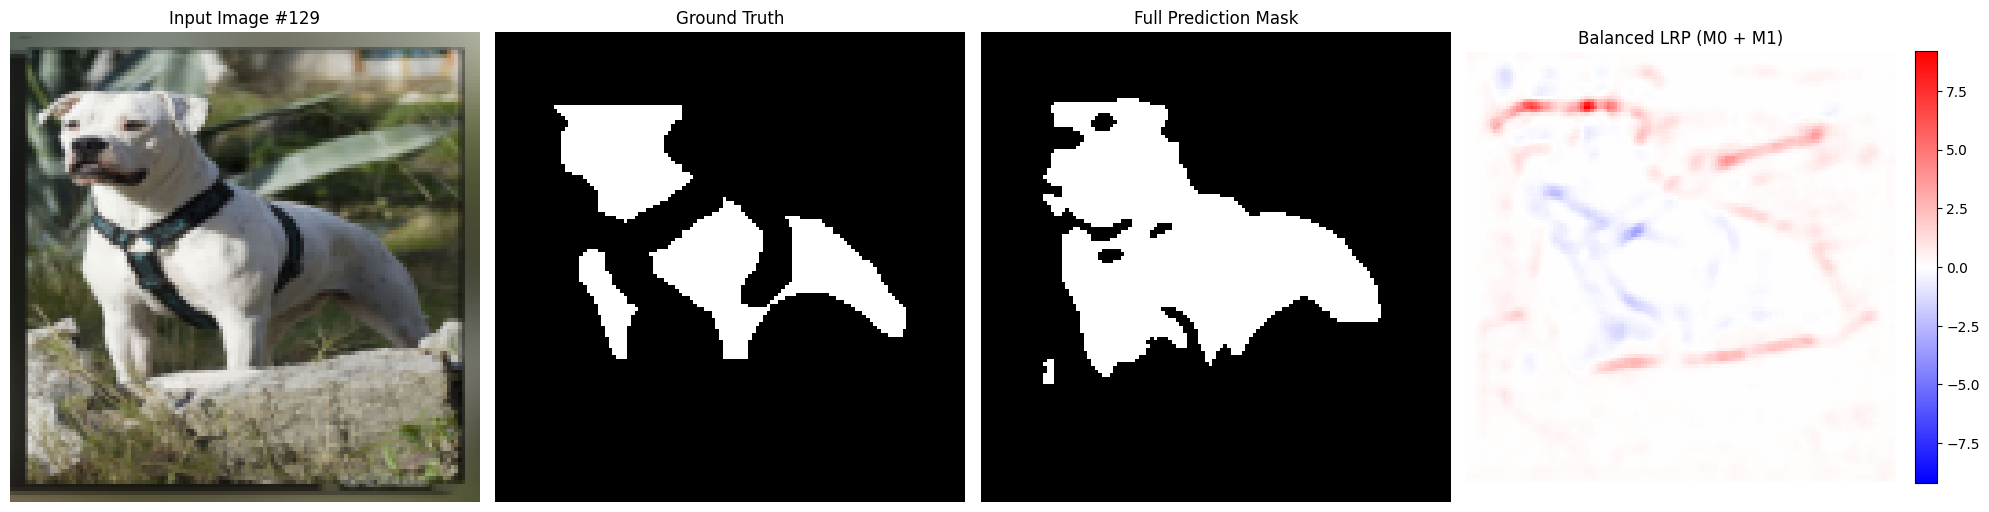

In [52]:
if __name__ == "__main__":
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    
    print(device)
    # Assuming val_ds and device are already defined in your script above!
    MODEL_PATH = "./models/unet.pth"
    
    # Run this to test a completely random image from the validation set:
    test_validation_image_balanced_lrp(MODEL_PATH, val_ds, device, 129)
    